## YOLO'X TRAINING ON BLOOD CELL CLASSIFICATION

In [1]:
%%capture
# Install PyTorch with CUDA
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Install additional dependencies
!pip install matplotlib pandas pillow torchtnt==0.2.0 tqdm

# Install extra dependencies for pandas
!pip install tabulate pyarrow fastparquet

# Install package for creating visually distinct colormaps
!pip install distinctipy

# Install utility packages
!pip install cjm_pandas_utils cjm_psl_utils cjm_pil_utils cjm_pytorch_utils cjm_yolox_pytorch cjm_torchvision_tfms

In [2]:
# Import Python Standard Library dependencies
import datetime
from functools import partial
from glob import glob
import json
import math
import multiprocessing
import os
from pathlib import Path
import random

# Import utility functions
from cjm_psl_utils.core import download_file, file_extract
from cjm_pil_utils.core import resize_img, get_img_files, stack_imgs
from cjm_pytorch_utils.core import tensor_to_pil, get_torch_device, set_seed, denorm_img_tensor
from cjm_pandas_utils.core import markdown_to_pandas, convert_to_numeric, convert_to_string
from cjm_torchvision_tfms.core import ResizeMax, PadSquare, CustomRandomIoUCrop, CustomRandomAugment

# Import YOLOX package
from cjm_yolox_pytorch.model import build_model, MODEL_CFGS, NORM_STATS
from cjm_yolox_pytorch.utils import generate_output_grids
from cjm_yolox_pytorch.loss import YOLOXLoss
from cjm_yolox_pytorch.inference import YOLOXInferenceWrapper

# Import the distinctipy module
from distinctipy import distinctipy

# Import matplotlib for creating plots
import matplotlib.pyplot as plt

# Import numpy
import numpy as np

# Import the pandas package
import pandas as pd

# Do not truncate the contents of cells and display all rows and columns
pd.set_option('max_colwidth', None, 'display.max_rows', None, 'display.max_columns', None)

# Import PIL for image manipulation
from PIL import Image

# Import PyTorch dependencies
import torch
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchtnt.utils import get_module_summary

# Import torchvision dependencies
import torchvision
torchvision.disable_beta_transforms_warning()
from torchvision.tv_tensors import BoundingBoxes
from torchvision.utils import draw_bounding_boxes
import torchvision.transforms.v2  as transforms
from torchvision.transforms.v2 import functional as TF

# Import tqdm for progress bar
from tqdm.auto import tqdm

In [3]:
seed = 42
set_seed(seed)
device = get_torch_device() # Returns string like 'cuda' or 'cpu'
dtype = torch.float32

train_sz = 256
bs = 16
epochs = 50
lr = 1e-3

# Robust path setup
input_dir = Path("/kaggle/input")
dataset_name = "blood-cell-detection-dataset"
dataset_path = input_dir/dataset_name

if not dataset_path.exists():
    # Try to find the dataset directory if the name is slightly different
    possible_dirs = [d for d in input_dir.iterdir() if d.is_dir()]
    if possible_dirs:
        dataset_path = possible_dirs[0]
        print(f"Dataset found at: {dataset_path}")

images_path = dataset_path/"images"
ann_path = dataset_path/"annotations.csv"

if not ann_path.exists():
    # Search for any csv in the dataset path
    csv_files = list(dataset_path.rglob("*.csv"))
    if csv_files:
        ann_path = csv_files[0]
        print(f"Annotations found at: {ann_path}")

project_dir = Path("/kaggle/working/yolox_blood_cell")
project_dir.mkdir(parents=True, exist_ok=True)

In [4]:
df = pd.read_csv(str(ann_path))

all_images = df['image'].unique().tolist()

random.shuffle(all_images)

train_split = int(0.8 * len(all_images))

val_split = int(0.9 * len(all_images))

train_keys = all_images[:train_split]

val_keys = all_images[train_split:val_split]

test_keys = all_images[val_split:]

class_names = sorted(df['label'].unique().tolist())

class_to_idx = {name: i for i, name in enumerate(class_names)}

print(f"Classes: {class_names}")
print(f"Train: {len(train_keys)}, val: {len(val_keys)}, Test: {len(test_keys)}")

Classes: ['rbc', 'wbc']
Train: 80, val: 10, Test: 10


In [5]:
class BloodCellDataset(Dataset):
    def __init__(self, img_keys, df, images_path, class_to_idx, transforms=None):
        self.img_keys = img_keys
        self.df = df.set_index('image')
        self.images_path = images_path
        self.class_to_idx = class_to_idx
        self.transforms = transforms

    def __len__(self):
        return len(self.img_keys)

    def __getitem__(self, idx):
        img_name = self.img_keys[idx]
        img_path = self.images_path/img_name
        image = Image.open(img_path).convert("RGB")
        
        rows = self.df.loc[[img_name]]
        bboxes = rows[['xmin', 'ymin', 'xmax', 'ymax']].values
        labels = [self.class_to_idx[l] for l in rows['label'].values]
        
        bboxes = torch.tensor(bboxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)
        
        target = {
            'boxes': BoundingBoxes(bboxes, format="xyxy", canvas_size=image.size[::-1]),
            'labels': labels
        }
        
        if self.transforms:
            image, target = self.transforms(image, target)
            
        return image, target

fill = (0, 0, 0)
norm_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

resize_pad_tfm = transforms.Compose([
    ResizeMax(max_sz=train_sz),
    PadSquare(shift=True, fill=fill),
    transforms.Resize([train_sz] * 2, antialias=True)
])

final_tfms = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.SanitizeBoundingBoxes(),
    transforms.Normalize(*norm_stats),
])

train_tfms = transforms.Compose([
    CustomRandomAugment(),
    resize_pad_tfm,
    final_tfms,
])

valid_tfms = transforms.Compose([resize_pad_tfm, final_tfms])

train_dataset = BloodCellDataset(train_keys, df, images_path, class_to_idx, train_tfms)
valid_dataset = BloodCellDataset(val_keys, df, images_path, class_to_idx, valid_tfms)

# Use parameters similar to the reference code for stability
num_workers = 0 # Forced to 0 for stability in notebooks
data_loader_params = {
    'batch_size': bs,
    'num_workers': num_workers,
    'collate_fn': lambda batch: tuple(zip(*batch)),
    'pin_memory': 'cuda' in device,
    'pin_memory_device': device if 'cuda' in device else ''
}

# Set drop_last=False for validation to avoid ZeroDivisionError if dataset is small
train_loader = DataLoader(train_dataset, **data_loader_params, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, **data_loader_params, drop_last=False)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}")

Train batches: 5, Valid batches: 1


In [6]:
model_type = 'yolox_tiny'
model = build_model(model_type, len(class_names), pretrained=True).to(device)

loss_func = YOLOXLoss(num_classes=len(class_names), bbox_loss_weight=10.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=epochs * len(train_loader))

  0%|          | 0.00/20.5M [00:00<?, ?iB/s]

In [7]:
def run_epoch(model, loader, optimizer, scheduler, loss_func, device, scaler, is_train):
    model.train() if is_train else model.eval()
    total_loss = 0
    
    if len(loader) == 0:
        return 0.0
        
    pbar = tqdm(loader, desc="Train" if is_train else "Eval")
    
    for batch_id, (inputs, targets) in enumerate(pbar):
        inputs = torch.stack(inputs).to(device)
        gt_boxes = [t['boxes'].to(device) for t in targets]
        gt_labels = [t['labels'].to(device) for t in targets]
        
        # Forward pass with Automatic Mixed Precision (AMP)
        with autocast(device_type=torch.device(device).type):
            cls_scores, bbox_preds, obj_scores = model(inputs)
            losses = loss_func(cls_scores, bbox_preds, obj_scores, gt_boxes, gt_labels)
            loss = sum(losses.values())
            
        if is_train:
            optimizer.zero_grad()
            if scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
            
            scheduler.step()
            
        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item(), avg_loss=total_loss/(batch_id+1))
        
        # Safety check for NaN loss
        if is_train and not math.isfinite(loss.item()):
            print(f"Loss is {loss.item()}, stopping training")
            break
        
    return total_loss / len(loader)

# Reverting to standard GradScaler() to avoid TypeError in some environments
scaler = GradScaler() if 'cuda' in device else None
best_val_loss = float('inf')

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    train_loss = run_epoch(model, train_loader, optimizer, scheduler, loss_func, device, scaler, True)
    with torch.no_grad():
        val_loss = run_epoch(model, valid_loader, None, None, loss_func, device, scaler, False)
        
    if val_loss < best_val_loss and val_loss > 0:
        best_val_loss = val_loss
        torch.save(model.state_dict(), project_dir/"best_model.pth")
        print("Saved best model!")

Epoch 1/50


/tmp/ipykernel_24/2164956793.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if 'cuda' in device else None


Train:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Eval:   0%|          | 0/1 [00:00<?, ?it/s]

...

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 50/50


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Eval:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
model.load_state_dict(torch.load(project_dir/"best_model.pth"))
model.eval()

mean_t = torch.tensor(norm_stats[0]).view(1, 3, 1, 1).to(device)
std_t = torch.tensor(norm_stats[1]).view(1, 3, 1, 1).to(device)
wrapped_model = YOLOXInferenceWrapper(model, mean_t, std_t)

def predict(img_path):
    img = Image.open(img_path).convert("RGB")
    resized = resize_img(img, target_sz=train_sz)
    input_t = transforms.Compose([transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)])(resized)[None].to(device)
    
    with torch.no_grad():
        output = wrapped_model(input_t).cpu()
    
    # Simple NMS/Filtering (simplified for demo)
    conf_thresh = 0.3
    mask = output[0, :, -1] > conf_thresh
    proposals = output[0, mask]
    
    if len(proposals) == 0: return resized
    
    boxes = torchvision.ops.box_convert(proposals[:, :4], 'xywh', 'xyxy')
    labels = [class_names[int(i)] for i in proposals[:, 4]]
    
    colors = distinctipy.get_colors(len(class_names))
    int_colors = [tuple(int(c*255) for c in color) for color in colors]
    
    annotated = draw_bounding_boxes(
        image=(transforms.PILToTensor()(resized)),
        boxes=boxes,
        labels=labels,
        colors=[int_colors[class_names.index(l)] for l in labels],
        width=2
    )
    return tensor_to_pil(annotated)

Best Validation Loss: 2.9901


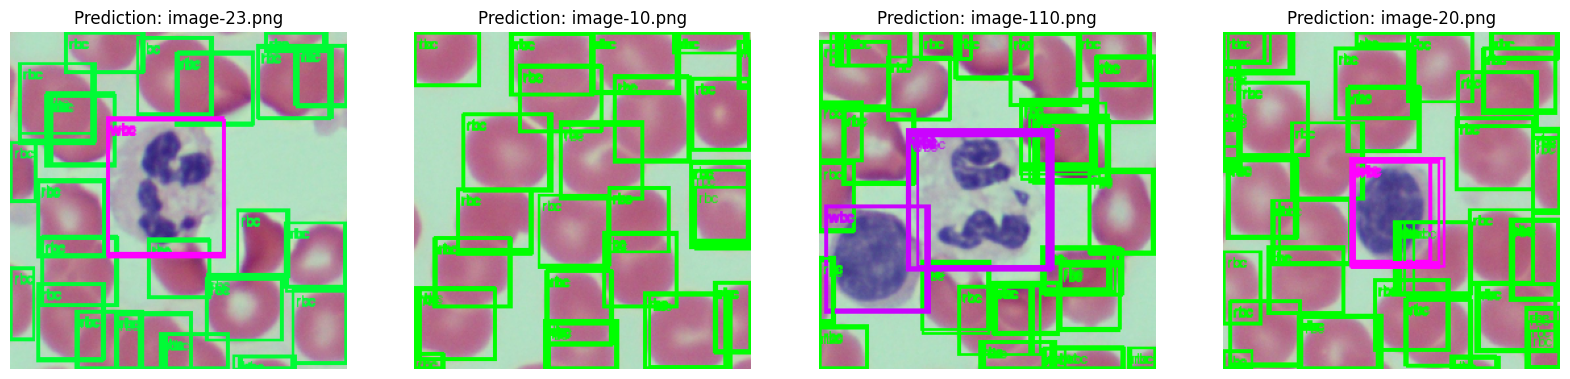

In [9]:
print(f"Best Validation Loss: {best_val_loss:.4f}")

# Visualize predictions on a few random test images
plt.figure(figsize=(20, 10))
for i in range(4):
    test_img_name = random.choice(test_keys)
    test_img_path = images_path/test_img_name
    prediction = predict(test_img_path)
    
    plt.subplot(1, 4, i+1)
    plt.imshow(prediction)
    plt.title(f"Prediction: {test_img_name}")
    plt.axis('off')
plt.show()